In [8]:
import pandas as pd

df = pd.read_csv("Students Social Media Addiction.csv")

print(df.shape)
df.head()
df.info()
df.describe()

(705, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  


,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


In [9]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.dropna()

In [11]:
df = df.drop('Student_ID', axis=1)

In [12]:
df['Brainrot_Score'] = (
    df['Avg_Daily_Usage_Hours'] * 2 +
    df['Conflicts_Over_Social_Media'] * 1.5 -
    df['Sleep_Hours_Per_Night'] * 1.2 -
    df['Mental_Health_Score'] * 0.8
)

In [13]:
df['Brainrot_Level'] = pd.qcut(
    df['Brainrot_Score'],
    q=3,
    labels=[0, 1, 2]
)

In [14]:
df['Mental_Health_Level'] = pd.qcut(
    df['Mental_Health_Score'],
    q=3,
    labels=[0, 1, 2]
)

df = df.drop('Mental_Health_Score', axis=1)

In [15]:
df = pd.get_dummies(df, drop_first=True)

In [16]:
X_cls = df.drop(['Addicted_Score', 'Brainrot_Score'], axis=1)
y_cls = df['Addicted_Score']

In [39]:
X_reg = df.drop(['Brainrot_Score', 'Addicted_Score'], axis=1)
y_reg = df['Brainrot_Score']

In [40]:
from sklearn.model_selection import train_test_split

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Xc_train = scaler.fit_transform(Xc_train)
Xc_test = scaler.transform(Xc_test)

Xr_train = scaler.fit_transform(Xr_train)
Xr_test = scaler.transform(Xr_test)

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(Xr_train, yr_train)

yr_pred = lr.predict(Xr_test)

print("R2 Score:", r2_score(yr_test, yr_pred))
print("MSE:", mean_squared_error(yr_test, yr_pred))

R2 Score: 0.9968596510934106
MSE: 0.09090427766739013


In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    random_state=42
)

rf.fit(Xc_train, yc_train)

yc_pred = rf.predict(Xc_test)

print("Accuracy:", accuracy_score(yc_test, yc_pred))
print(classification_report(yc_test, yc_pred))

Accuracy: 0.9574468085106383
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         1
           3       1.00      1.00      1.00         2
           4       0.94      1.00      0.97        15
           5       1.00      1.00      1.00        35
           6       1.00      0.89      0.94         9
           7       0.93      1.00      0.96        41
           8       0.93      0.93      0.93        28
           9       1.00      0.80      0.89        10

    accuracy                           0.96       141
   macro avg       0.85      0.83      0.84       141
weighted avg       0.95      0.96      0.95       141



C:\Users\krish\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\krish\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\krish\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [44]:
def predict_user(data):
    data_scaled = scaler.transform([data])
    
    addiction = rf.predict(data_scaled)[0]
    brainrot = lr.predict(data_scaled)[0]
    
    if brainrot < 10:
        level = "Low"
    elif brainrot < 25:
        level = "Medium"
    else:
        level = "High"
    
    return {
        "Addiction_Score": addiction,
        "Brainrot_Score": brainrot,
        "Brainrot_Level": level
    }

In [45]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(yc_test, yc_pred))

Accuracy: 0.9574468085106383


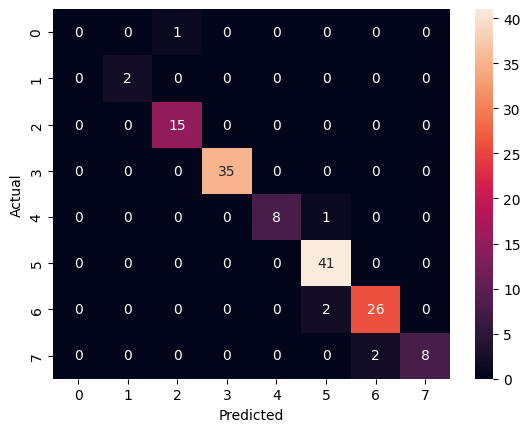

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(yc_test, yc_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

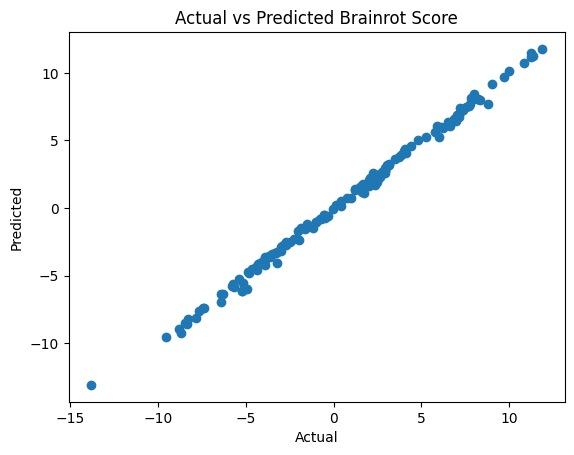

In [47]:
plt.scatter(yr_test, yr_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Brainrot Score")
plt.show()

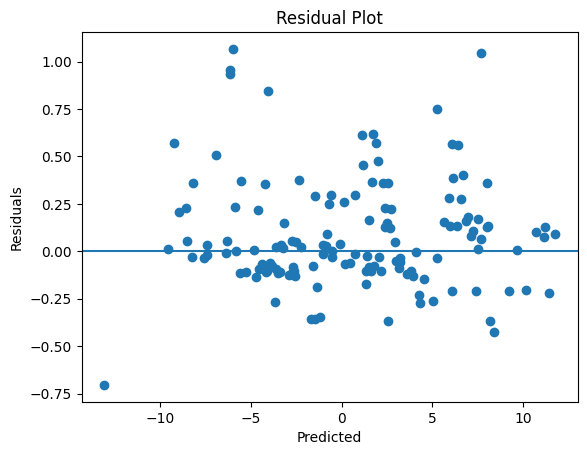

In [48]:
residuals = yr_test - yr_pred

plt.scatter(yr_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [49]:
print("Train Accuracy:", rf.score(Xc_train, yc_train))
print("Test Accuracy:", rf.score(Xc_test, yc_test))

Train Accuracy: 0.9645390070921985
Test Accuracy: 0.9574468085106383


In [50]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X_cls, y_cls, cv=5)

print(scores)
print("Average:", scores.mean())

C:\Users\krish\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


[0.77304965 0.85106383 0.95035461 0.95035461 0.80141844]
Average: 0.8652482269503545


In [51]:
import pickle

pickle.dump(rf, open("addiction_model.pkl", "wb"))
pickle.dump(lr, open("brainrot_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))


# Save column names
pickle.dump(X_cls.columns, open("columns.pkl", "wb"))